# Evaluacion de modelos

Resumen de los modelos entrenados en `models/builded/`: metricas, comparacion contra baseline y graficos rapidos para decidir que modelos son fiables.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "models" / "builded").exists():
    ROOT = ROOT.parent

BUILD_DIR = ROOT / "models" / "builded"
METRICS_PATH = BUILD_DIR / "metrics.csv"
REGISTRY_PATH = BUILD_DIR / "registry.json"

metrics = pd.read_csv(METRICS_PATH, encoding="utf-8-sig")
registry = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))

metrics["mae_improvement"] = metrics["baseline_mae"] - metrics["mae"]
metrics["mae_improvement_pct"] = 100 * metrics["mae_improvement"] / metrics["baseline_mae"]
metrics["beats_baseline_mae"] = metrics["beats_baseline_mae"].astype(bool)

print(f"Modelos evaluados: {len(metrics)}")
print(f"Fecha de entrenamiento: {metrics['trained_at_utc'].max()}")
print(f"Mejoran baseline: {metrics['beats_baseline_mae'].sum()}/{len(metrics)}")


Modelos evaluados: 64
Fecha de entrenamiento: 2026-06-23T02:31:40+00:00
Mejoran baseline: 47/64


In [3]:
overview = (
    metrics
    .groupby(["pollutant", "horizon_hours"], as_index=False)
    .agg(
        models=("model_path", "count"),
        mae=("mae", "mean"),
        baseline_mae=("baseline_mae", "mean"),
        rmse=("rmse", "mean"),
        r2=("r2", "mean"),
        beats_baseline=("beats_baseline_mae", "sum"),
        mae_improvement_pct=("mae_improvement_pct", "mean"),
    )
    .sort_values(["pollutant", "horizon_hours"])
)

display(overview)


,pollutant,horizon_hours,models,mae,baseline_mae,rmse,r2,beats_baseline,mae_improvement_pct
0,NO2,8,8,10.634991,14.702779,13.383795,0.245236,8,26.047856
1,NO2,24,8,10.255391,10.300460,13.244244,0.296704,5,-0.267933
2,O3,8,6,10.338276,10.794038,13.136049,0.384850,3,3.026836
3,O3,24,6,11.679987,12.501076,14.406211,0.250192,6,6.218521
4,PM10,8,6,2.272754,2.869419,3.084407,0.892277,6,19.166880
5,PM10,24,6,6.100654,6.847627,8.061593,0.240210,5,6.820577
6,PM2.5,8,6,1.131395,1.521282,1.622570,0.928825,6,25.432399
7,PM2.5,24,6,3.318490,3.717356,4.590669,0.402404,6,10.146687
8,SO2,8,6,0.430814,0.401286,0.633351,0.030220,2,-84.759989
9,SO2,24,6,0.442223,0.315816,0.641467,-0.048182,0,-105.928770


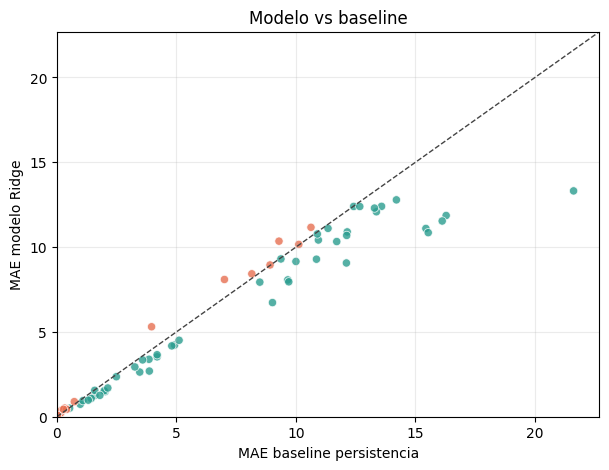

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = np.where(metrics["beats_baseline_mae"], "#2a9d8f", "#e76f51")
ax.scatter(metrics["baseline_mae"], metrics["mae"], c=colors, alpha=0.8, edgecolor="white", linewidth=0.6)
limit = max(metrics["baseline_mae"].max(), metrics["mae"].max()) * 1.05
ax.plot([0, limit], [0, limit], color="#444", linestyle="--", linewidth=1)
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel("MAE baseline persistencia")
ax.set_ylabel("MAE modelo Ridge")
ax.set_title("Modelo vs baseline")
ax.grid(True, alpha=0.25)
plt.show()


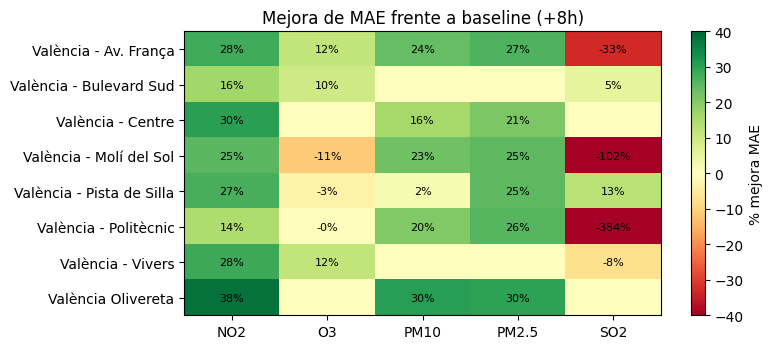

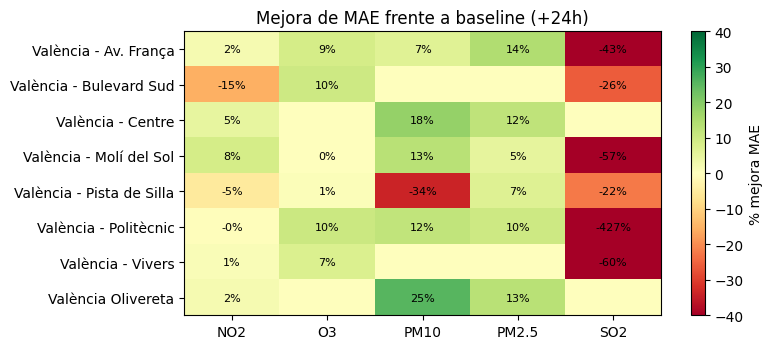

In [5]:
for horizon in sorted(metrics["horizon_hours"].unique()):
    subset = metrics[metrics["horizon_hours"] == horizon]
    pivot = subset.pivot_table(
        index="station",
        columns="pollutant",
        values="mae_improvement_pct",
        aggfunc="mean",
    )

    fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(pivot))))
    image = ax.imshow(pivot.fillna(0), cmap="RdYlGn", vmin=-40, vmax=40, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_title(f"Mejora de MAE frente a baseline (+{horizon}h)")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            label = "" if pd.isna(value) else f"{value:.0f}%"
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label="% mejora MAE")
    plt.tight_layout()
    plt.show()


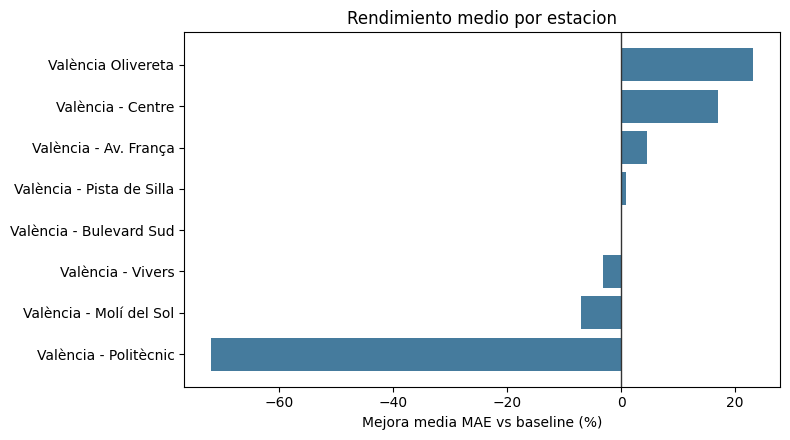

,station,models,beats,avg_improvement_pct,avg_r2
5,València - Politècnic,10,6,-71.953340,0.164575
3,València - Molí del Sol,10,7,-7.046477,0.410353
6,València - Vivers,6,4,-3.141406,0.224935
1,València - Bulevard Sud,6,4,-0.019634,0.245426
4,València - Pista de Silla,10,6,0.952392,0.381593
0,València - Av. França,10,8,4.558149,0.376774
2,València - Centre,6,6,16.964576,0.522492
7,València Olivereta,6,6,23.174963,0.588370


In [6]:
by_station = (
    metrics
    .groupby("station", as_index=False)
    .agg(
        models=("model_path", "count"),
        beats=("beats_baseline_mae", "sum"),
        avg_improvement_pct=("mae_improvement_pct", "mean"),
        avg_r2=("r2", "mean"),
    )
    .sort_values("avg_improvement_pct")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(by_station["station"], by_station["avg_improvement_pct"], color="#457b9d")
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("Mejora media MAE vs baseline (%)")
ax.set_title("Rendimiento medio por estacion")
plt.tight_layout()
plt.show()

display(by_station)


In [7]:
best = metrics.sort_values("mae_improvement_pct", ascending=False).head(10)
worst = metrics.sort_values("mae_improvement_pct", ascending=True).head(10)

print("Mejores modelos")
display(best[["station", "pollutant", "horizon_hours", "mae", "baseline_mae", "mae_improvement_pct", "r2", "model_path"]])

print("Modelos a vigilar")
display(worst[["station", "pollutant", "horizon_hours", "mae", "baseline_mae", "mae_improvement_pct", "r2", "model_path"]])


Mejores modelos


,station,pollutant,horizon_hours,mae,baseline_mae,mae_improvement_pct,r2,model_path
58,València Olivereta,NO2,8,13.312805,21.615721,38.411466,0.349893,models/builded/model__valencia_olivereta__no2_...
60,València Olivereta,PM10,8,2.691675,3.867209,30.397490,0.907364,models/builded/model__valencia_olivereta__pm10...
16,València - Centre,NO2,8,10.852006,15.534985,30.144728,0.266407,models/builded/model__valencia_centre__no2__h0...
62,València Olivereta,PM2.5,8,1.261146,1.797093,29.822979,0.934121,models/builded/model__valencia_olivereta__pm2_...
54,València - Vivers,NO2,8,11.538224,16.119670,28.421465,0.199427,models/builded/model__valencia_vivers__no2__h0...
2,València - Av. França,NO2,8,11.098789,15.437037,28.102852,0.357740,models/builded/model__valencia_av_franca__no2_...
34,València - Pista de Silla,NO2,8,11.862521,16.284712,27.155477,0.253125,models/builded/model__valencia_pista_de_silla_...
8,València - Av. França,PM2.5,8,1.479993,2.014830,26.544991,0.933621,models/builded/model__valencia_av_franca__pm2_...
50,València - Politècnic,PM2.5,8,0.977393,1.313385,25.582188,0.927319,models/builded/model__valencia_politecnic__pm2...
61,València Olivereta,PM10,24,6.728760,9.018889,25.392577,0.437867,models/builded/model__valencia_olivereta__pm10...


Modelos a vigilar


,station,pollutant,horizon_hours,mae,baseline_mae,mae_improvement_pct,r2,model_path
43,València - Politècnic,SO2,24,0.092870,0.017621,-427.039615,-1.059487,models/builded/model__valencia_politecnic__so2...
42,València - Politècnic,SO2,8,0.083396,0.017217,-384.393283,-0.828773,models/builded/model__valencia_politecnic__so2...
22,València - Molí del Sol,SO2,8,0.382095,0.189415,-101.723847,0.631609,models/builded/model__valencia_moli_del_sol__s...
53,València - Vivers,SO2,24,0.438155,0.273876,-59.982673,0.144790,models/builded/model__valencia_vivers__so2__h2...
23,València - Molí del Sol,SO2,24,0.509467,0.324638,-56.934121,0.398426,models/builded/model__valencia_moli_del_sol__s...
1,València - Av. França,SO2,24,0.239974,0.167401,-43.352689,-0.154001,models/builded/model__valencia_av_franca__so2_...
39,València - Pista de Silla,PM10,24,5.304081,3.960482,-33.925130,0.024228,models/builded/model__valencia_pista_de_silla_...
0,València - Av. França,SO2,8,0.230969,0.173601,-33.045901,-0.140946,models/builded/model__valencia_av_franca__so2_...
11,València - Bulevard Sud,SO2,24,0.483061,0.383178,-26.067180,0.176847,models/builded/model__valencia_bulevard_sud__s...
33,València - Pista de Silla,SO2,24,0.889813,0.728183,-22.196345,0.204335,models/builded/model__valencia_pista_de_silla_...


## Lectura rapida

- Si un punto queda por debajo de la diagonal, el modelo mejora la persistencia.
- En los mapas de calor, verde significa que Ridge reduce el MAE frente al baseline; rojo significa que empeora.
- Los modelos marcados como peores no hay que borrarlos necesariamente, pero conviene no publicarlos como prediccion principal si pierden contra persistencia.
